<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/oilrefineries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crude-oil preflash and atmospheric flash-zone screening with NeqSim

**Audience.** Process and facilities engineers, refinery students, and NeqSim users who need a
reproducible first model of a crude-unit front end.

**Prerequisites.** Basic familiarity with mole and mass fractions, absolute pressure, enthalpy,
phase equilibrium, and Python tables is useful. The notebook uses no private assay or local file.

## Learning objectives

After completing this notebook, you can:

1. represent light hydrocarbons and assay cuts as NeqSim components and TBP pseudo-components;
2. convert a molar assay into mass-based refinery cut yields;
3. assemble a composable preheater, preflash drum, furnace, and atmospheric flash zone;
4. verify total mass, component, and heater-energy closure;
5. interpret light-vapor, atmospheric-vapor, and residue product distributions;
6. screen furnace-temperature, flash-pressure, and EOS sensitivity; and
7. distinguish a flash-zone screening model from a rated atmospheric distillation column.

## Engineering context

A crude distillation unit first removes light ends, then heats the remaining oil before it enters
the atmospheric column flash zone. The real column has pump-around circuits, stripping steam,
side draws, reflux, and many non-ideal stages. This tutorial deliberately models the thermodynamic
front end:

**crude feed → preheater → preflash drum → furnace → atmospheric flash zone**.

The three material products are preflash vapor, atmospheric vapor, and atmospheric residue. The
model is suitable for concept screening, heat-load understanding, and building a larger process
model. It is not a refinery licensor design.

## Assay representation

The synthetic assay contains named light hydrocarbons and six true-boiling-point (TBP)
pseudo-components. For component $i$, the mass fraction derived from molar composition is

$$
w_i = \frac{z_i M_i}{\sum_j z_j M_j}
$$

Here $z_i$ is mole fraction, $M_i$ is molar mass in kg/mol, and $w_i$ is mass fraction. A refinery
cut yield is the sum of the component mass fractions assigned to that boiling range:

$$
Y_k = \sum_{i \in k} w_i
$$

The cut labels are engineering groupings of this synthetic assay, not ASTM D86 or laboratory TBP
measurements.

## Thermodynamic model

The base case uses Peng–Robinson with the classic mixing rule. PR is widely used for hydrocarbon
vapor–liquid equilibrium and liquid-rich petroleum systems. NeqSim estimates properties of each
TBP pseudo-component from its supplied molar mass and density.

At equilibrium, each component has equal fugacity in vapor and liquid:

$$
f_i^{\mathrm{vapor}} = f_i^{\mathrm{liquid}}
$$

This compact relation drives every TP flash and separator calculation. Heavy-end characterization,
binary parameters, and the equation of state must be calibrated before design use.

## Process balances and heater duty

For the complete steady-state front end, the total mass balance is

$$
\dot{m}_F = \dot{m}_{V1} + \dot{m}_{V2} + \dot{m}_R
$$

and component $i$ must satisfy

$$
\dot{n}_{i,F} = \dot{n}_{i,V1} + \dot{n}_{i,V2} + \dot{n}_{i,R}
$$

The heater calculation is checked independently from stream enthalpies:

$$
\dot{Q} = \dot{H}_{\mathrm{out}} - \dot{H}_{\mathrm{in}}
$$

Mass flow is reported in kg/h, molar flow in mol/s, pressure in bara, temperature in °C, and heat
duty in kW.

## Assumptions and validity limits

- steady-state equilibrium flashes with no chemical reaction or coke formation;
- PR thermodynamics with classic mixing and a normalized synthetic molar assay;
- no water, salt, sulfur chemistry, metals, solids, or asphaltene precipitation;
- no stripping steam, tray efficiency, side draws, reflux, pump-around, or vacuum section;
- no fired-heater radiation model, tube-wall temperature, pressure drop, or coking constraint;
- the preflash operates at 180°C and 3 bara; the atmospheric flash zone at 350°C and 2 bara;
- heat-loss and mechanical-design allowances are excluded.

The calculation supports screening and teaching. It cannot certify product specifications,
column diameter, heater design, emissions, corrosion, or safe operating limits.

## 1. Clean Google Colab setup

The setup cell upgrades NeqSim from public PyPI and records the actual package, Python, and Java
versions associated with the stored outputs.

In [1]:
import importlib.metadata
import subprocess
import sys


install_command = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "--upgrade",
    "--no-cache-dir",
    "neqsim",
]
subprocess.run(
    install_command,
    check=True,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

neqsim_version = importlib.metadata.version("neqsim")
java_result = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
)
java_version = java_result.stderr.splitlines()[0]
python_version = sys.version.split()[0]

print(f"NeqSim: {neqsim_version}")
print(f"Python: {python_version}")
print(f"Java: {java_version}")

NeqSim: 3.16.0
Python: 3.12.13
Java: openjdk version "17.0.19" 2026-04-21


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim.process import (
    clearProcess,
    heater,
    runProcess,
    separator,
    stream,
)
from neqsim.thermo import TPflash, fluid


pd.set_option("display.precision", 6)

## 2. Define a reproducible synthetic crude assay

Light components are entered explicitly. Each TBP fraction is defined by a name, molar amount,
molar mass in kg/mol, and liquid density in kg/m³. These are transparent teaching inputs rather
than unexplained default values.

In [3]:
light_component_data = [
    ("methane", 0.005),
    ("ethane", 0.005),
    ("propane", 0.010),
    ("n-butane", 0.020),
    ("n-pentane", 0.030),
    ("n-hexane", 0.050),
]
tbp_fraction_data = [
    ("C7-C9", 0.120, 0.105, 750.0),
    ("C10-C12", 0.150, 0.145, 780.0),
    ("C13-C16", 0.180, 0.205, 820.0),
    ("C17-C24", 0.220, 0.300, 870.0),
    ("C25-C35", 0.120, 0.430, 920.0),
    ("C36+", 0.090, 0.650, 970.0),
]

input_mole_fraction_sum = sum(
    amount
    for _, amount in light_component_data
) + sum(
    amount
    for _, amount, _, _ in tbp_fraction_data
)

assert math.isclose(
    input_mole_fraction_sum,
    1.0,
    rel_tol=0.0,
    abs_tol=1.0e-12,
)
print(f"Input mole-fraction sum: {input_mole_fraction_sum:.12f}")

Input mole-fraction sum: 1.000000000000


In [4]:
def build_synthetic_crude(model_name):
    crude_fluid = fluid(model_name)

    for component_name, amount in light_component_data:
        crude_fluid.addComponent(component_name, amount)

    for name, amount, molar_mass, density in tbp_fraction_data:
        crude_fluid.addTBPfraction(
            name,
            amount,
            molar_mass,
            density,
        )

    crude_fluid.setMixingRule("classic")
    crude_fluid.init(0)
    return crude_fluid


crude_fluid = build_synthetic_crude("pr")
print("Base thermodynamic model: Peng–Robinson with classic mixing")

Base thermodynamic model: Peng–Robinson with classic mixing


## 3. Inspect pseudo-component properties and refinery cuts

NeqSim appends `_PC` to TBP pseudo-component names. Normal boiling points are model properties in
kelvin and are converted to °C here. The grouping function assigns each component to one broad
refinery cut so the mass distribution can be interpreted before any process calculation.

In [5]:
def refinery_cut_name(normal_boiling_point_c):
    if normal_boiling_point_c < 30.0:
        return "light ends / LPG"

    if normal_boiling_point_c < 180.0:
        return "naphtha"

    if normal_boiling_point_c < 270.0:
        return "kerosene"

    if normal_boiling_point_c < 370.0:
        return "atmospheric gas oil"

    return "vacuum gas oil / residue"


assay_records = []

for component_index in range(crude_fluid.getNumberOfComponents()):
    component = crude_fluid.getComponent(component_index)
    boiling_point_c = component.getNormalBoilingPoint() - 273.15
    assay_records.append(
        {
            "component": str(component.getComponentName()),
            "mole fraction [-]": component.getz(),
            "molar mass [kg/mol]": component.getMolarMass(),
            "normal boiling point [°C]": boiling_point_c,
            "refinery cut": refinery_cut_name(boiling_point_c),
        }
    )

assay_table = pd.DataFrame(assay_records)
mass_basis = (
    assay_table["mole fraction [-]"]
    * assay_table["molar mass [kg/mol]"]
)
assay_table["mass fraction [-]"] = mass_basis / mass_basis.sum()

display(assay_table)

,component,mole fraction [-],molar mass [kg/mol],normal boiling point [°C],refinery cut,mass fraction [-]
0,methane,0.005,0.016043,-161.550000,light ends / LPG,0.000314
1,ethane,0.005,0.030070,-88.550000,light ends / LPG,0.000588
2,propane,0.010,0.044097,-42.050000,light ends / LPG,0.001725
3,n-butane,0.020,0.058123,-0.450000,light ends / LPG,0.004547
4,n-pentane,0.030,0.072150,36.050000,naphtha,0.008466
5,n-hexane,0.050,0.086177,68.750000,naphtha,0.016854
6,C7-C9_PC,0.120,0.105000,114.349250,naphtha,0.049285
7,C10-C12_PC,0.150,0.145000,179.143250,naphtha,0.085075
8,C13-C16_PC,0.180,0.205000,260.794250,kerosene,0.144334
9,C17-C24_PC,0.220,0.300000,357.680000,atmospheric gas oil,0.258158


In [6]:
cut_order = [
    "light ends / LPG",
    "naphtha",
    "kerosene",
    "atmospheric gas oil",
    "vacuum gas oil / residue",
]
feed_cut_yields = (
    assay_table.groupby("refinery cut")["mass fraction [-]"]
    .sum()
    .reindex(cut_order, fill_value=0.0)
)

cut_yield_table = pd.DataFrame(
    {
        "refinery cut": cut_order,
        "feed mass yield [%]": 100.0 * feed_cut_yields.to_numpy(),
    }
)
display(cut_yield_table)
print(f"Cut-yield sum: {feed_cut_yields.sum():.12f}")

Cut-yield sum: 1.000000000000


,refinery cut,feed mass yield [%]
0,light ends / LPG,0.717364
1,naphtha,15.967994
2,kerosene,14.433382
3,atmospheric gas oil,25.815804
4,vacuum gas oil / residue,43.065455


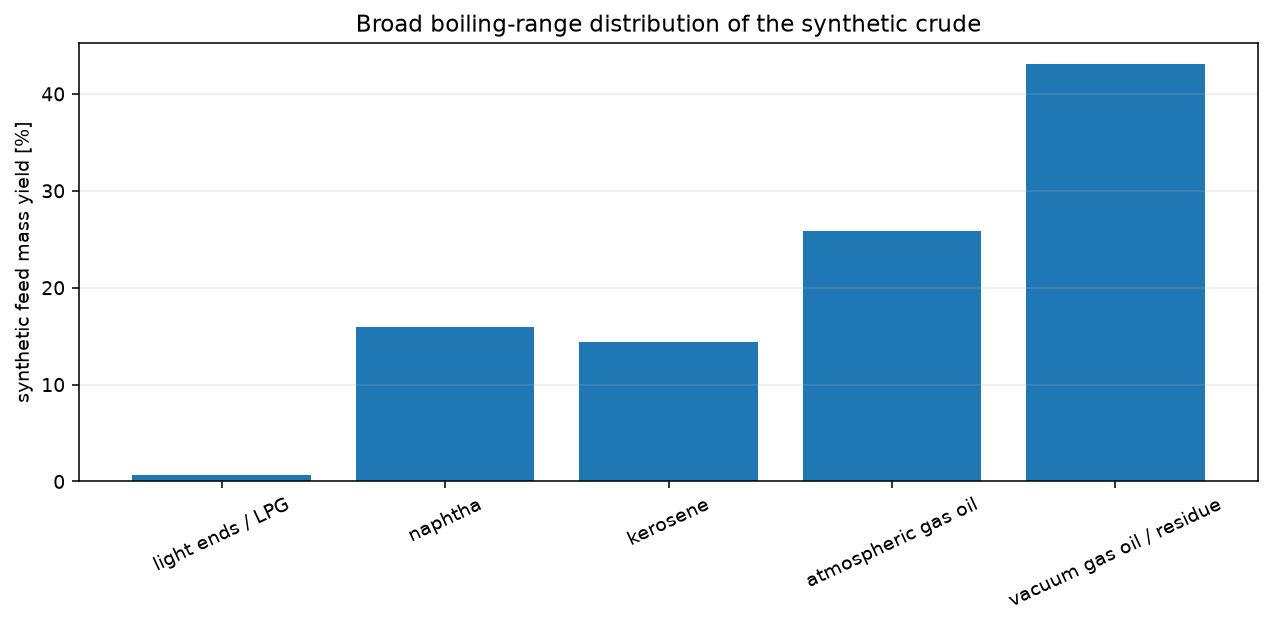

In [7]:
figure, axis = plt.subplots(figsize=(9.2, 4.6))
axis.bar(
    cut_order,
    100.0 * feed_cut_yields.to_numpy(),
    color="tab:blue",
)
axis.set_ylabel("synthetic feed mass yield [%]")
axis.set_title("Broad boiling-range distribution of the synthetic crude")
axis.tick_params(axis="x", rotation=25)
axis.grid(axis="y", alpha=0.25)
figure.tight_layout()
plt.show()

## 4. Reusable stream and component reporting

A NeqSim stream contains a total flow and an overall thermodynamic composition. Multiplying total
molar rate by overall mole fraction reconstructs each component rate independently for the later
balance. Molecular-weight conversion then gives component mass flow in kg/h.

In [8]:
component_names = assay_table["component"].tolist()
component_molar_masses = assay_table["molar mass [kg/mol]"].to_numpy()
component_cut_names = assay_table["refinery cut"].tolist()


def component_molar_rates(stream_object):
    stream_fluid = stream_object.getFluid()
    total_rate = stream_object.getFlowRate("mole/sec")
    component_rates = []

    for component_name in component_names:
        mole_fraction = stream_fluid.getComponent(component_name).getz()
        component_rates.append(total_rate * mole_fraction)

    return np.asarray(component_rates)


def component_mass_rates_kg_h(stream_object):
    molar_rates = component_molar_rates(stream_object)
    return molar_rates * component_molar_masses * 3600.0


def stream_state(stream_object):
    return {
        "mass flow [kg/h]": stream_object.getFlowRate("kg/hr"),
        "temperature [°C]": stream_object.getTemperature("C"),
        "pressure [bara]": stream_object.getPressure("bara"),
        "phases [-]": stream_object.getFluid().getNumberOfPhases(),
    }

## 5. Build the refinery front-end flowsheet

The feed rate is 100,000 kg/h. The preheater creates a warm, low-pressure state and the preflash
drum removes volatile material. Only the preflash liquid enters the atmospheric furnace. The final
separator represents the atmospheric flash zone, not the complete fractionation tower.

In [9]:
clearProcess()

crude_feed = stream("synthetic crude feed", crude_fluid)
crude_feed.setFlowRate(100_000.0, "kg/hr")
crude_feed.setTemperature(25.0, "C")
crude_feed.setPressure(10.0, "bara")

preheater = heater("crude preheater", crude_feed)
preheater.setOutTemperature(180.0, "C")
preheater.setOutPressure(3.0, "bara")

preflash_drum = separator(
    "preflash drum",
    preheater.getOutletStream(),
)

atmospheric_furnace = heater(
    "atmospheric furnace",
    preflash_drum.getLiquidOutStream(),
)
atmospheric_furnace.setOutTemperature(350.0, "C")
atmospheric_furnace.setOutPressure(2.0, "bara")

atmospheric_flash_zone = separator(
    "atmospheric flash zone",
    atmospheric_furnace.getOutletStream(),
)

## 6. Execute the connected process

One process run solves every unit in dependency order. The result-bearing streams are assigned
stable names immediately afterward so all checks refer to the same solved objects.

In [10]:
runProcess()

preheated_crude = preheater.getOutletStream()
preflash_vapor = preflash_drum.getGasOutStream()
preflash_liquid = preflash_drum.getLiquidOutStream()
furnace_outlet = atmospheric_furnace.getOutletStream()
atmospheric_vapor = atmospheric_flash_zone.getGasOutStream()
atmospheric_residue = atmospheric_flash_zone.getLiquidOutStream()

print("Refinery front-end calculation completed.")

Refinery front-end calculation completed.


## 7. Inspect state and flow results

Both flash drums conserve total flow while redistributing components. The preflash removes a small
light stream. The hotter atmospheric flash produces a larger vapor stream and a heavy liquid
residue.

In [11]:
state_table = pd.DataFrame.from_dict(
    {
        "crude feed": stream_state(crude_feed),
        "preheated crude": stream_state(preheated_crude),
        "preflash vapor": stream_state(preflash_vapor),
        "preflash liquid": stream_state(preflash_liquid),
        "furnace outlet": stream_state(furnace_outlet),
        "atmospheric vapor": stream_state(atmospheric_vapor),
        "atmospheric residue": stream_state(atmospheric_residue),
    },
    orient="index",
)
display(state_table)

,mass flow [kg/h],temperature [°C],pressure [bara],phases [-]
crude feed,100000.000000,25.0,10.0,1
preheated crude,100000.000000,180.0,3.0,2
preflash vapor,1776.477901,180.0,3.0,1
preflash liquid,98223.522099,180.0,3.0,1
furnace outlet,98223.522099,350.0,2.0,2
atmospheric vapor,38966.657455,350.0,2.0,1
atmospheric residue,59256.864645,350.0,2.0,1


## 8. Close total and component balances

The complete front-end products are the two vapor streams and the atmospheric residue. Component
residuals are reconstructed in mol/s; total mass residual is checked directly in kg/h.

In [12]:
feed_component_rates = component_molar_rates(crude_feed)
preflash_component_rates = component_molar_rates(preflash_vapor)
atmospheric_component_rates = component_molar_rates(atmospheric_vapor)
residue_component_rates = component_molar_rates(atmospheric_residue)

component_residuals = (
    preflash_component_rates
    + atmospheric_component_rates
    + residue_component_rates
    - feed_component_rates
)
maximum_component_residual = np.max(np.abs(component_residuals))

mass_residual_kg_h = (
    preflash_vapor.getFlowRate("kg/hr")
    + atmospheric_vapor.getFlowRate("kg/hr")
    + atmospheric_residue.getFlowRate("kg/hr")
    - crude_feed.getFlowRate("kg/hr")
)

balance_table = pd.DataFrame(
    {
        "component": component_names,
        "feed [mol/s]": feed_component_rates,
        "preflash vapor [mol/s]": preflash_component_rates,
        "atmospheric vapor [mol/s]": atmospheric_component_rates,
        "residue [mol/s]": residue_component_rates,
        "residual [mol/s]": component_residuals,
    }
)
display(balance_table)
print(f"Mass residual: {mass_residual_kg_h:.3e} kg/h")
print(f"Maximum component residual: {maximum_component_residual:.3e} mol/s")

Mass residual: 2.321e-08 kg/h
Maximum component residual: 8.097e-12 mol/s


,component,feed [mol/s],preflash vapor [mol/s],atmospheric vapor [mol/s],residue [mol/s],residual [mol/s]
0,methane,0.543262,4.761387e-01,0.066884,0.000240,-2.964295e-14
1,ethane,0.543262,4.045047e-01,0.137948,0.000810,-6.039613e-14
2,propane,1.086524,6.561500e-01,0.426779,0.003594,-1.849632e-13
3,n-butane,2.173048,9.674606e-01,1.191248,0.014339,-5.115908e-13
4,n-pentane,3.259571,9.974220e-01,2.225104,0.037045,-9.476864e-13
5,n-hexane,5.432619,1.079482e+00,4.256715,0.096422,-1.794120e-12
6,C7-C9_PC,13.038285,1.343389e+00,11.310115,0.384781,-4.680700e-12
7,C10-C12_PC,16.297856,4.637847e-01,14.822564,1.011508,-5.783818e-12
8,C13-C16_PC,19.557428,7.049139e-02,16.292046,3.194890,-4.941825e-12
9,C17-C24_PC,23.903523,2.493375e-03,10.758884,13.142146,4.227729e-12


## 9. Verify heater energy balances

NeqSim reports heater duty in watts. The same value is reconstructed from the inlet and outlet
stream enthalpy rates. Agreement demonstrates consistent process-unit bookkeeping; it is not an
independent experimental heat-duty benchmark.

In [13]:
preheater_duty_w = preheater.getDuty()
preheater_enthalpy_change_w = (
    preheated_crude.getFluid().getEnthalpy("J")
    - crude_feed.getFluid().getEnthalpy("J")
)
preheater_energy_residual_w = (
    preheater_duty_w
    - preheater_enthalpy_change_w
)

furnace_duty_w = atmospheric_furnace.getDuty()
furnace_enthalpy_change_w = (
    furnace_outlet.getFluid().getEnthalpy("J")
    - preflash_liquid.getFluid().getEnthalpy("J")
)
furnace_energy_residual_w = furnace_duty_w - furnace_enthalpy_change_w

energy_table = pd.DataFrame(
    {
        "unit": ["crude preheater", "atmospheric furnace"],
        "reported duty [kW]": [
            preheater_duty_w / 1000.0,
            furnace_duty_w / 1000.0,
        ],
        "enthalpy change [kW]": [
            preheater_enthalpy_change_w / 1000.0,
            furnace_enthalpy_change_w / 1000.0,
        ],
        "residual [W]": [
            preheater_energy_residual_w,
            furnace_energy_residual_w,
        ],
    }
)
display(energy_table)

,unit,reported duty [kW],enthalpy change [kW],residual [W]
0,crude preheater,9456.718234,9456.718234,0.0
1,atmospheric furnace,14931.989455,14931.989455,0.0


## 10. Interpret broad cut flow in each product

Component mass rates are grouped using the same boiling-range labels as the feed assay. This does
not create finished products, but it clearly shows which boiling ranges leave in each flash stream
and which remain in atmospheric residue.

In [14]:
product_streams = {
    "preflash vapor": preflash_vapor,
    "atmospheric vapor": atmospheric_vapor,
    "atmospheric residue": atmospheric_residue,
}
product_cut_flows = pd.DataFrame(
    0.0,
    index=cut_order,
    columns=list(product_streams),
)

for product_name, product_stream in product_streams.items():
    component_mass_flows = component_mass_rates_kg_h(product_stream)

    for cut_name, component_mass_flow in zip(
        component_cut_names,
        component_mass_flows,
    ):
        product_cut_flows.loc[cut_name, product_name] += component_mass_flow

display(product_cut_flows)

,preflash vapor,atmospheric vapor,atmospheric residue
light ends / LPG,377.885190,335.806844,3.672452
naphtha,1343.862585,13911.141430,712.990177
kerosene,52.022649,12023.529998,2357.828878
atmospheric gas oil,2.692845,11619.594324,14193.517184
vacuum gas oil / residue,0.014631,1076.584859,41988.855953


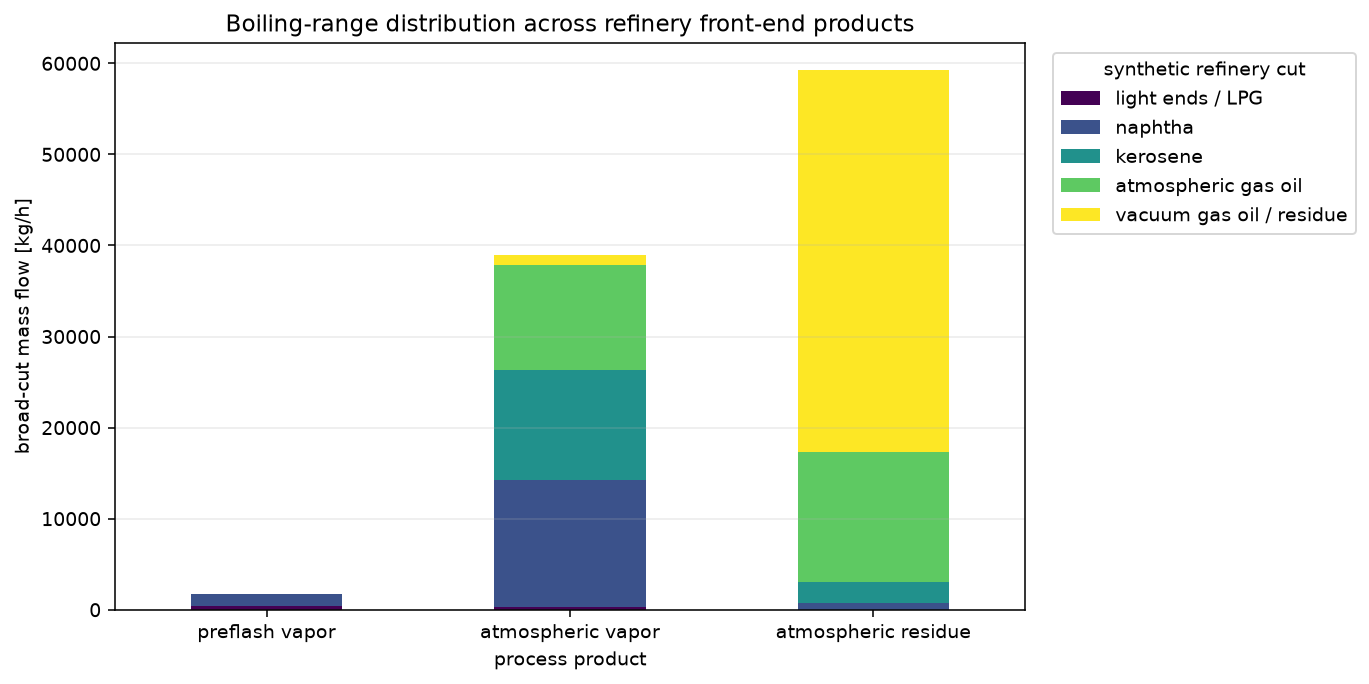

In [15]:
figure, axis = plt.subplots(figsize=(10.0, 5.0))
product_cut_flows.T.plot(
    kind="bar",
    stacked=True,
    ax=axis,
    colormap="viridis",
)
axis.set_ylabel("broad-cut mass flow [kg/h]")
axis.set_xlabel("process product")
axis.set_title("Boiling-range distribution across refinery front-end products")
axis.tick_params(axis="x", rotation=0)
axis.grid(axis="y", alpha=0.25)
axis.legend(title="synthetic refinery cut", bbox_to_anchor=(1.02, 1.0))
figure.tight_layout()
plt.show()

## 11. Furnace-temperature sensitivity

An equilibrium TP-flash sweep isolates the thermodynamic effect of flash-zone temperature at
2 bara. Vapor phase fraction is molar. Increasing temperature should vaporize more of the crude,
but real heater limits and thermal cracking prevent unconstrained temperature increases.

In [16]:
temperature_cases_c = np.asarray(
    [
        280.0,
        300.0,
        320.0,
        340.0,
        350.0,
        360.0,
        380.0,
    ]
)
temperature_vapor_fractions = []

for temperature_c in temperature_cases_c:
    temperature_case = crude_fluid.clone()
    TPflash(
        temperature_case,
        float(temperature_c),
        "C",
        2.0,
        "bara",
    )
    vapor_fraction = temperature_case.getPhase("gas").getBeta()
    temperature_vapor_fractions.append(float(vapor_fraction))

temperature_sensitivity = pd.DataFrame(
    {
        "flash temperature [°C]": temperature_cases_c,
        "vapor mole fraction [-]": temperature_vapor_fractions,
    }
)
display(temperature_sensitivity)

,flash temperature [°C],vapor mole fraction [-]
0,280.0,0.426472
1,300.0,0.488975
2,320.0,0.551763
3,340.0,0.615488
4,350.0,0.646788
5,360.0,0.676791
6,380.0,0.731256


## 12. Pressure and EOS sensitivity

Lower flash pressure increases vaporization. PR and SRK are then compared at the base flash-zone
condition. Their spread is model-form uncertainty for this synthetic characterization, not a
measure of either model's accuracy against a real assay.

In [17]:
pressure_cases_bara = np.asarray([1.5, 2.0, 3.0, 4.0, 5.0])
pressure_vapor_fractions = []

for pressure_bara in pressure_cases_bara:
    pressure_case = crude_fluid.clone()
    TPflash(
        pressure_case,
        350.0,
        "C",
        float(pressure_bara),
        "bara",
    )
    vapor_fraction = pressure_case.getPhase("gas").getBeta()
    pressure_vapor_fractions.append(float(vapor_fraction))

eos_results = {}

for model_name in ["pr", "srk"]:
    eos_case = build_synthetic_crude(model_name)
    TPflash(
        eos_case,
        350.0,
        "C",
        2.0,
        "bara",
    )
    eos_results[model_name.upper()] = eos_case.getPhase("gas").getBeta()

eos_spread = abs(eos_results["PR"] - eos_results["SRK"])
print(f"PR vapor mole fraction: {eos_results['PR']:.6f}")
print(f"SRK vapor mole fraction: {eos_results['SRK']:.6f}")
print(f"Absolute EOS spread: {eos_spread:.6f}")

PR vapor mole fraction: 0.646788
SRK vapor mole fraction: 0.744888
Absolute EOS spread: 0.098101


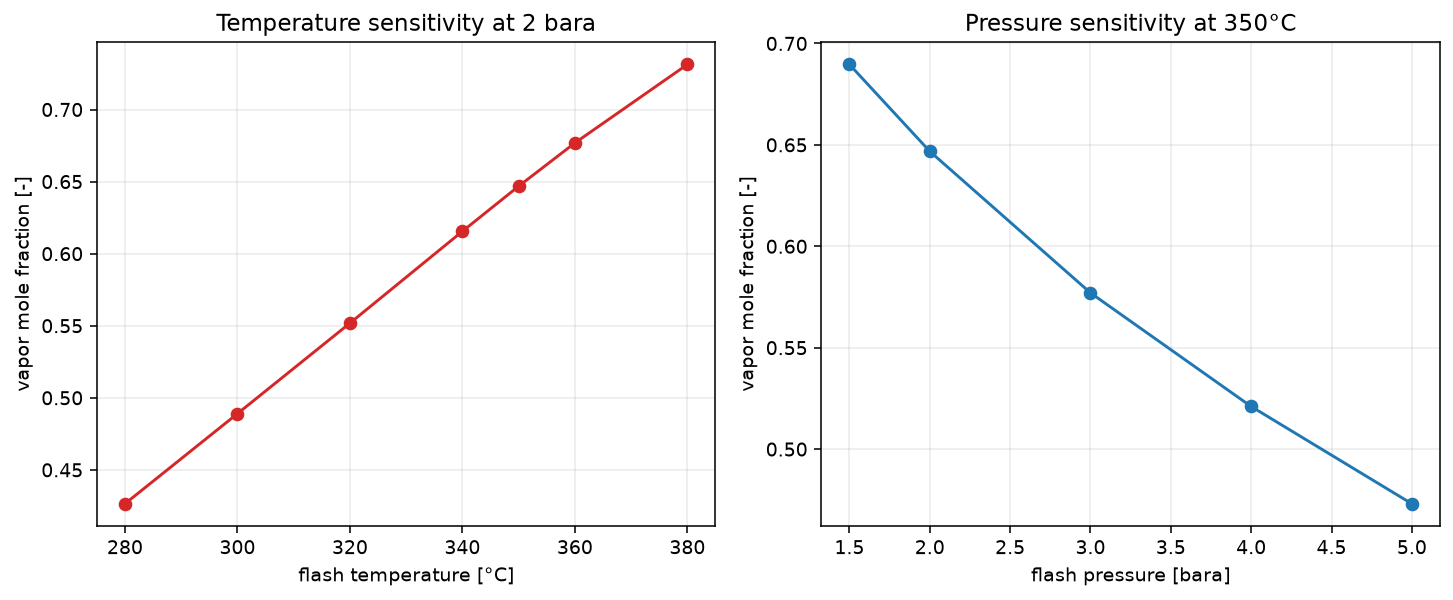

In [18]:
figure, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))

axes[0].plot(
    temperature_cases_c,
    temperature_vapor_fractions,
    marker="o",
    color="tab:red",
)
axes[0].set_xlabel("flash temperature [°C]")
axes[0].set_ylabel("vapor mole fraction [-]")
axes[0].set_title("Temperature sensitivity at 2 bara")
axes[0].grid(alpha=0.25)

axes[1].plot(
    pressure_cases_bara,
    pressure_vapor_fractions,
    marker="o",
    color="tab:blue",
)
axes[1].set_xlabel("flash pressure [bara]")
axes[1].set_ylabel("vapor mole fraction [-]")
axes[1].set_title("Pressure sensitivity at 350°C")
axes[1].grid(alpha=0.25)

figure.tight_layout()
plt.show()

## 13. Heat-intensity and recovery screening

The unintegrated specific heat input is

$$
e_Q = \frac{\dot{Q}_{\mathrm{preheat}} + \dot{Q}_{\mathrm{furnace}}}{\dot{m}_F}
$$

with $e_Q$ in kWh/t when heat is in kW and feed is in t/h. A simple heat-recovery illustration
credits a fraction $\eta_{\mathrm{rec}}$ of the preheater duty:

$$
\dot{Q}_{\mathrm{purchased}} =
\dot{Q}_{\mathrm{furnace}} +
(1-\eta_{\mathrm{rec}})\dot{Q}_{\mathrm{preheat}}
$$

This is transparent accounting, not a heat-exchanger-network optimization.

In [19]:
feed_rate_t_h = crude_feed.getFlowRate("kg/hr") / 1000.0
heat_recovery_fractions = np.asarray([0.0, 0.50, 0.75])
specific_energy_kwh_t = []

for heat_recovery_fraction in heat_recovery_fractions:
    purchased_heat_kw = (
        furnace_duty_w
        + (1.0 - heat_recovery_fraction) * preheater_duty_w
    ) / 1000.0
    specific_energy = purchased_heat_kw / feed_rate_t_h
    specific_energy_kwh_t.append(specific_energy)

heat_recovery_table = pd.DataFrame(
    {
        "preheater duty recovered [%]": 100.0 * heat_recovery_fractions,
        "purchased heat intensity [kWh/t]": specific_energy_kwh_t,
    }
)
display(heat_recovery_table)

,preheater duty recovered [%],purchased heat intensity [kWh/t]
0,0.0,243.887077
1,50.0,196.603486
2,75.0,172.961690


## 14. Focused engineering validation

The checks below establish conservation, finite and ordered states, physically expected trends,
consistent cut accounting, and bounded EOS sensitivity. They validate this notebook's screening
calculation; they do not validate the synthetic assay against refinery operating data.

In [20]:
product_mass_flow_kg_h = sum(
    product_stream.getFlowRate("kg/hr")
    for product_stream in product_streams.values()
)
grouped_product_mass_kg_h = product_cut_flows.to_numpy().sum()
feed_heavy_fraction = feed_cut_yields.loc["vacuum gas oil / residue"]
residue_cut_mass = product_cut_flows["atmospheric residue"]
residue_heavy_fraction = (
    residue_cut_mass.loc["vacuum gas oil / residue"]
    / residue_cut_mass.sum()
)
preflash_cut_mass = product_cut_flows["preflash vapor"]
preflash_light_fraction = (
    preflash_cut_mass.loc["light ends / LPG"]
    / preflash_cut_mass.sum()
)
feed_light_fraction = feed_cut_yields.loc["light ends / LPG"]

engineering_checks = {
    "all reported stream states are finite": np.isfinite(
        state_table.to_numpy()
    ).all(),
    "three product streams are positive": all(
        product_stream.getFlowRate("kg/hr") > 0.0
        for product_stream in product_streams.values()
    ),
    "overall mass balance closes": abs(mass_residual_kg_h) < 1.0e-5,
    "component balances close": maximum_component_residual < 1.0e-8,
    "grouped product mass matches stream mass": abs(
        grouped_product_mass_kg_h - product_mass_flow_kg_h
    ) < 1.0e-4,
    "feed cut yields sum to unity": math.isclose(
        feed_cut_yields.sum(),
        1.0,
        rel_tol=0.0,
        abs_tol=1.0e-12,
    ),
    "preheater energy closes": abs(preheater_energy_residual_w) < 1.0e-5,
    "furnace energy closes": abs(furnace_energy_residual_w) < 1.0e-5,
    "both heating duties are positive": (
        preheater_duty_w > 0.0
        and furnace_duty_w > 0.0
    ),
    "preflash state is hotter and lower pressure": (
        preheated_crude.getTemperature("C") > crude_feed.getTemperature("C")
        and preheated_crude.getPressure("bara") < crude_feed.getPressure("bara")
    ),
    "furnace outlet is hotter and lower pressure": (
        furnace_outlet.getTemperature("C") > preflash_liquid.getTemperature("C")
        and furnace_outlet.getPressure("bara") < preflash_liquid.getPressure("bara")
    ),
    "temperature raises vapor fraction": np.all(
        np.diff(temperature_vapor_fractions) > 0.0
    ),
    "pressure lowers vapor fraction": np.all(
        np.diff(pressure_vapor_fractions) < 0.0
    ),
    "all sensitivity vapor fractions are bounded": all(
        0.0 < vapor_fraction < 1.0
        for vapor_fraction in (
            temperature_vapor_fractions
            + pressure_vapor_fractions
        )
    ),
    "EOS results are bounded": all(
        0.0 < vapor_fraction < 1.0
        for vapor_fraction in eos_results.values()
    ),
    "EOS spread is finite and below 0.20": (
        math.isfinite(eos_spread)
        and eos_spread < 0.20
    ),
    "residue is enriched in the heavy cut": (
        residue_heavy_fraction > feed_heavy_fraction
    ),
    "preflash vapor is enriched in light ends": (
        preflash_light_fraction > feed_light_fraction
    ),
    "heat recovery reduces purchased intensity": np.all(
        np.diff(specific_energy_kwh_t) < 0.0
    ),
    "TBP normal boiling points increase": np.all(
        np.diff(
            assay_table.loc[
                assay_table["component"].str.endswith("_PC"),
                "normal boiling point [°C]",
            ]
        ) > 0.0
    ),
}

failed_checks = [
    check_name
    for check_name, check_passed in engineering_checks.items()
    if not check_passed
]
assert not failed_checks, f"Failed engineering checks: {failed_checks}"

validation_table = pd.DataFrame(
    {
        "check": list(engineering_checks),
        "passed": list(engineering_checks.values()),
    }
)
display(validation_table)
print(f"All {len(engineering_checks)} engineering checks passed.")

All 20 engineering checks passed.


,check,passed
0,all reported stream states are finite,True
1,three product streams are positive,True
2,overall mass balance closes,True
3,component balances close,True
4,grouped product mass matches stream mass,True
5,feed cut yields sum to unity,True
6,preheater energy closes,True
7,furnace energy closes,True
8,both heating duties are positive,True
9,preflash state is hotter and lower pressure,True


## Engineering interpretation

The preflash removes a small light-rich stream before high-temperature heating. The atmospheric
flash then divides the remaining crude into a vapor stream rich in lighter boiling ranges and a
residue enriched in vacuum-gas-oil and residue pseudo-components. Higher furnace temperature and
lower flash pressure increase equilibrium vaporization, while the PR–SRK spread shows why a real
assay and calibration matter.

The unintegrated heat intensity is intentionally high because no product-to-feed heat recovery is
modeled. The recovery table quantifies the first-order value of a crude preheat train without
pretending to optimize exchanger matches or temperature approaches.

## Troubleshooting and practical limitations

- If pseudo-components are missing, check molar mass in kg/mol and density in kg/m³.
- Initialize the fluid after adding TBP fractions before reading normalized mole fractions.
- Inspect phase existence before requesting a named gas or oil phase in extreme sensitivity cases.
- Do not interpret equilibrium vapor as a finished naphtha, kerosene, or gas-oil product.
- Replace the synthetic assay with authorized TBP or simulated-distillation data for project work.
- Add the atmospheric column, stripping steam, side draws, pump-arounds, and reflux for product
  specification studies.
- Rate the furnace separately for tube-wall temperature, heat flux, pressure drop, coking, fuel,
  emissions, draft, and safeguarding.
- Couple exchanger-network optimization to minimum approach temperatures and fouling allowances.

## Summary, further exercises, and references

This notebook turns the former setup-only placeholder into an executed refinery tutorial. It
defines a transparent crude assay, builds reusable NeqSim process objects, retains calculated
tables and plots, and validates mass, components, energy, boiling-range allocation, EOS response,
and operating trends.

### Exercises

1. Replace one broad TBP fraction with three narrower cuts and quantify flash-yield sensitivity.
2. Add water and salt only after selecting and validating a suitable aqueous thermodynamic model.
3. Route atmospheric vapor through a condenser and three-phase separator.
4. Build a separately validated staged atmospheric column with side-draw product targets.
5. Add product-to-feed exchangers and optimize heat recovery subject to approach constraints.
6. Compare the synthetic curve with authorized laboratory TBP or simulated-distillation data.

### References

- [NeqSim getting-started guide and heavy-fraction example](https://equinor.github.io/neqsim/wiki/getting_started.html)
- [NeqSim process simulation package](https://equinor.github.io/neqsim/process/README.html)
- [NeqSim thermodynamics recipes](https://equinor.github.io/neqsim/cookbook/thermodynamics-recipes.html)
- API Technical Data Book, petroleum fraction characterization and distillation sections.
- J. H. Gary, G. E. Handwerk, and M. J. Kaiser, *Petroleum Refining: Technology and Economics*.